In [1]:
#import important things

import matplotlib.pyplot as plt
import rebound
import numpy as np
import pandas as pd
import scipy
import math
import random
from scipy.optimize import minimize
#from scipy.integrate import solve_ivp, odeint
from scipy.signal import find_peaks

In [2]:
def setup_tri(j, k, mutot, etilde, pomega2, lambda_target, ind, iterations = 20):
    ecross = 2*k/(3*j)
    n1 = 2*np.pi
    n2 = n1*(j-k)/j
    tconj = 2*np.pi/(n1-n2) # estimate for time between conjunctions
    t0 = -0.8*tconj

    lambda10 = lambda_target+n1*t0 # this should be exact since 
    lambda20 = lambda_target+n2*t0

    setupSim=rebound.Simulation()
    setupSim.add(m=1)
    
    if ind == 1:
        setupSim.add(P=j/(j-k), e=etilde*ecross, pomega=pomega2, l=lambda_target)
        x_target = setupSim.particles[1].x
    else:
        setupSim.add(P=1, e=etilde*ecross, pomega=pomega2, l=lambda_target)
        x_target = setupSim.particles[1].x

    if ind == 1: #inner pair
        lambda_20_prev = lambda20 # initial guess
        correction = 0
        for i in range(iterations):
            lambda_20 = lambda_20_prev + correction
            sim = rebound.Simulation()
            sim.add(m=1)
            sim.add(primary=sim.particles[0], m=mutot, P=1, l=lambda10)
            sim.add(primary=sim.particles[0], P=j/(j-k), e=etilde*ecross, pomega=pomega2, l=lambda_20)
            var_l = sim.add_variation()
            var_l.vary(2, 'l') # how does everything depend on the initial l of particles[2]
            sim.t = t0
            ps = sim.particles
            
            sim.integrate(0)
            correction = (x_target - ps[2].x)/var_l.particles[2].x
            lambda_20_prev = lambda_20
            #print('***',i,'***')
            #print(lambda_20_prev, ps[2].l, lambda_target-ps[2].l, correction)
        
       
        lambda_20 = lambda_20_prev + correction
        sim = rebound.Simulation()
        sim.add(m=1)
        sim.add(primary=sim.particles[0], m=mutot, P=1, l=lambda10)
        sim.add(primary=sim.particles[0], P=j/(j-k), e=etilde*ecross, pomega=pomega2, l=lambda_20)
    else: #outer pair
        lambda_10_prev = lambda10 # initial guess
        correction = 0
        for i in range(iterations):
            lambda_10 = lambda_10_prev + correction
            sim = rebound.Simulation()
            sim.add(m=1)
            sim.add(primary=sim.particles[0],P=1,e=etilde*ecross, pomega=pomega2, l=lambda_10)
            sim.add(primary=sim.particles[0],m=mutot, P=j/(j-k), l=lambda20)
            var_l = sim.add_variation()
            var_l.vary(1, 'l') # how does everything depend on the initial l of particles[2]
            sim.t = t0
            ps = sim.particles
        
            sim.integrate(0)
            correction = (x_target - ps[1].x)/var_l.particles[1].x
            lambda_10_prev = lambda_10
            #print('***',i,'***')
            #print(lambda_10_prev, ps[2].l, lambda_target-ps[2].l, correction)
        
       
        lambda_10 = lambda_10_prev + correction
        sim = rebound.Simulation()
        sim.add(m=1)
        sim.add(primary=sim.particles[0], P=1,e=etilde*ecross, pomega=pomega2, l=lambda_10)
        sim.add(primary=sim.particles[0], m=mutot, P=j/(j-k), l=lambda20)
    sim.t = t0
    return sim

In [3]:
def unwrap_l(ps):
    ''' given a sim.particles object ps, returns relative lambda (l) value of the planets
        removing the 2*pi discontinuities that result when one planet has crossed l=0 but
        the other has not
    '''
    if ps[2].l - ps[1].l > np.pi:
        return ps[2].l - ps[1].l - 2*np.pi
    elif ps[2].l - ps[1].l < -np.pi:
        return ps[2].l - ps[1].l + 2*np.pi
    else:
        return ps[2].l - ps[1].l

In [4]:
def new_run(sim, Nconj, Nout, ind):
    '''
    This function runs the Nbody simulation until we get Nconj conjunctions 
    and save the orbital parameters and conjunction times.
    '''
    # this function now saves individual semimajor axis length and other individual variables (will keep adding)
    ps = sim.particles
    n1 = ps[1].n
    n2 = ps[2].n
    tmin = sim.t
    #print(tmin)
    tconj = 2*np.pi/(n1-n2)
    tmax = Nconj*tconj + 0.8*tmin

    a12_arr, l12_arr, l2, theta_arr, pomega_arr, e12_arr, diffn_arr = np.zeros(Nout), np.zeros(Nout), np.zeros(Nout), np.zeros(Nout), np.zeros(Nout), np.zeros(Nout), np.zeros(Nout)
    e1, e2, pomega1, pomega2, a1_arr, a2_arr = np.zeros(Nout), np.zeros(Nout), np.zeros(Nout), np.zeros(Nout), np.zeros(Nout), np.zeros(Nout)
    n1_arr, n2_arr = np.zeros(Nout), np.zeros(Nout)
    l1 = np.zeros(Nout)
    times = np.linspace(tmin, tmax, Nout)
    #print(times)
    for i, time in enumerate(times):
        if ind==1:
            a12_arr[i] = (ps[2].a - ps[1].a)/ps[1].a # relative semimajor axis (a-a_p)/a_p
        else:
            a12_arr[i] = (ps[1].a - ps[2].a)/ps[2].a # now the second index is the planet
        a1_arr[i] = ps[1].a
        a2_arr[i] = ps[2].a
        l12_arr[i] = unwrap_l(ps) 
        e1_vec_temp= ps[1].e * np.exp(1j * ps[1].pomega)
        e2_vec_temp= ps[2].e * np.exp(1j * ps[2].pomega)
        if ind==1:
            pomega12_temp = np.angle(e2_vec_temp-e1_vec_temp)
            e12_temp = np.abs(e2_vec_temp-e1_vec_temp)
        else:
            pomega12_temp = np.angle(e1_vec_temp-e2_vec_temp)
            e12_temp = np.abs(e1_vec_temp-e2_vec_temp)
        theta_arr[i] = ps[2].l - pomega12_temp

        l1[i] = ps[1].l
        l2[i] = ps[2].l
        pomega_arr[i] = pomega12_temp
        e12_arr[i] = e12_temp

        n1_arr[i] = ps[1].n
        n2_arr[i] = ps[2].n
        e1[i] = ps[1].e
        e2[i] = ps[2].e
        pomega1[i] = ps[1].pomega
        pomega2[i] = ps[2].pomega
        diffn_arr[i] = ps[1].n - ps[2].n
        sim.integrate(time)

    l1 = np.unwrap(l1)
    l2 = np.unwrap(l2)
    
    # conjunctions occur at minima pf dl = maxima of -dl
    conj_idx, _ = find_peaks(-np.abs(l12_arr))
    if len(conj_idx) != Nconj:
        print("WARNING: wrong number of conjunction events found \n {} conjunctions found, {} conjunctions input".format(len(conj_idx), Nconj))
        #raise Exception('''wrong number of conjunction events found \n {} conjunctions found, 
        #                {} conjunctions input'''.format(len(conj_idx), Nconj))
    #pts_btwn_conj = (.5*np.diff(conj_idx)).astype(np.int64)

    btwn_conj_idx, properties = find_peaks(np.abs(l12_arr))
    #btwn_conj_idx[1:] = conj_idx[:-1] + pts_btwn_conj

    return [times, a12_arr, l12_arr, theta_arr, l1, l2, pomega_arr, e12_arr, e1, e2, pomega1, pomega2, diffn_arr, conj_idx, btwn_conj_idx, a1_arr, a2_arr, n1_arr, n2_arr]


In [5]:
def wrap_angles(angles):
    return (angles + np.pi) % (2 * np.pi) - np.pi

In [6]:
#Parameters and initial conditions
#mean motion resonance ratio
j = 12
k = 1
mutot = 1e-7 #mass of the planet
etilde=0.1 #eccentricity
pomega2=0
lambda_target= np.pi # where we want conjunction to happen/ analogous to lambda0 in lizzy's
Nconj = 1000 #number of conjunctions
Nout = Nconj*100
ind = 1# 1 for inner pair, 3 for outer pair
order = 2 # mapping order: 1 for first, 2 for second
ecross = 2*k/(3*j)
print(ecross)
print(etilde*ecross)

0.05555555555555555
0.005555555555555556


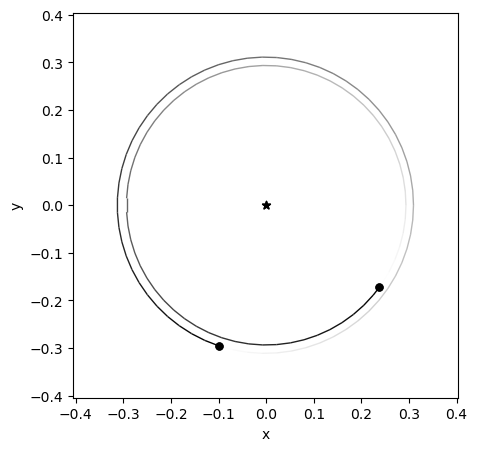

In [7]:
#Setup the nbody simulation to extract initial parameters and save others to compare
#sim = setup_dup(j,k,mutot,etilde,pomega2,lambda_target)
sim = setup_tri(j,k,mutot,etilde,pomega2,lambda_target,ind)
ps = sim.particles
#sim.integrate(0)
rebound.OrbitPlot(sim)

In [8]:
#parameters from simulation
times, a12, l12, theta2, l1, l2, pomega12, e12, e1, e2, pomega1, pomega2, diffn_arr, conj_idx, btwn_conj_idx, a1_arr, a2_arr, n1_arr, n2_arr = new_run(sim, Nconj, Nout, ind)
tconjs = times[conj_idx]  
tbetweens = times[btwn_conj_idx]  
an = a12[btwn_conj_idx]              # Relative semimajor axis
e12n = e12[btwn_conj_idx]            # Relative eccentricity
#individual values
a1_conj = a1_arr[btwn_conj_idx] 
a2_conj = a2_arr[btwn_conj_idx]
e1_conj = e1[btwn_conj_idx]
e2_conj = e2[btwn_conj_idx]
pomega1_conj = pomega1[btwn_conj_idx]
pomega2_conj = pomega2[btwn_conj_idx]
pomegan = pomega12[btwn_conj_idx]    # Relative periapse
if ind == 1:
    lambdan = l2[conj_idx]               # Lambda at conjunctions
else:
    lambdan = l1[conj_idx]  
diffnconj = diffn_arr[conj_idx]

if Nconj != len(conj_idx):
    Nconj = len(conj_idx)
    print("wrong number of conjunctions fixed")

In [9]:
#extract values for Namouni mapping and use in the equations
epsilon = (mutot/3)**(1/3)                      # Small mass parameter

print(epsilon)
eps0 = an[0]                                    # relative semimajor axis (scaled) - curly epsilon in DQT
ar0 = an[0] / epsilon                           # Initial scaled semimajor axis in Hill's unit
K0 = 3/8*ar0**2
I0 = (e12n[0]/epsilon)**2 / 2                   #Initial action
phi0 = pomegan[0] 

lambda0 = lambdan[0]                            # Initial conj angle

#eccentricity vector components
h0 = np.sqrt(2*I0)*np.cos(phi0)
k0 = np.sqrt(2*I0)*np.sin(phi0)

fe0 = np.abs(1/((1+an[0])**(-3/2)-1))
#beta0 = lambda0 - np.pi*fe0 + np.pi #opposition longitude, theta in dqt but we rename it because theta is already used
# print(eps0)
print(lambda_target, np.mod(lambda0, 2*np.pi), h0, k0, I0,K0)
# print(phi0, np.arctan2(k0,h0))
# print(ar0, ar0*epsilon)
# print(fe0, beta0)

#extract eccentricity vector components
e1_vec = e1_conj[0] * np.exp(1j * pomega1_conj[0])
#e1_vecarr = [np.real(e1_vec), np.imag(e1_vec)]
e2_vec = e2_conj[0] * np.exp(1j * pomega2_conj[0])
#e2_vecarr = [np.real(e2_vec), np.imag(e2_vec)]
if ind==1:
    z0 = e2_vec - e1_vec
else:
    z0 = e1_vec - e2_vec
# print(np.angle(z0), phi0)

0.0032182979486854338
3.141592653589793 3.1497019259603647 1.7262623358814408 2.4807358541430295e-05 1.4899908264491268 129.13053440595246


In [16]:
#Namouni mapping setup
W1, W2, W3, W4, W200 = 3.359350011, -2.678665722, 2.639498803, 2.8559, -1 #constants from the expansion
g = 2.23956667
#%% Namouni Mapping Functions
def calc_coeff(q, Wq, ar, theta):
    """Coefficient for power series in Namouni for the q'th order (derivatives of W wrt phi)."""
    return 2*q*2**(q/2)*Wq*np.sin(2*theta)/ar**(q+1)

def namouni_fo_step(In, Kn, phin, lambdan, arn, ind):
    """First-order Namouni mapping step."""
    hn = np.sqrt(2*In)*np.cos(phin)
    kn = np.sqrt(2*In)*np.sin(phin)
    if ind == 1:
        hprime = hn - 2*W1*np.sin(lambdan)/arn**2 # + for Namouni, - for pomega
        kprime = kn + 2*W1*np.cos(lambdan)/arn**2 # - for Namouni, + for pomega
    else: #from DQT, the sign switches for the outer pair
        hprime = hn + 2*W1*np.sin(lambdan)/arn**2 # + for Namouni, - for pomega
        kprime = kn - 2*W1*np.cos(lambdan)/arn**2 # - for Namouni, + for pomega
    phiprime = np.arctan2(kprime, hprime) # 4 quadrant arctan
    #print(hn, kn)
    # both options should give the same result:
    Inprime = 1/2*(hprime**2 + kprime**2)
    #Inprime = In + 2*W1/arn**2*np.sqrt(2*In)*np.sin(thetan) + 2*W1**2/arn**4
    #Namouni update
    hnp1 = hprime
    knp1 = kprime
    Inp1 = Inprime
    Knp1 = Kn + Inp1 - In
    phinp1 = phiprime
    lambdanp1 = lambdan + 4*np.pi/(3*epsilon*np.sqrt(8*Knp1/3))
    
    return Inp1, Knp1, phinp1, lambdanp1, hnp1, knp1

def namouni_so_step(In, Kn, phin, lambdan, arn, ind):
    """Second-order Namouni mapping step."""
    hn = np.sqrt(2*In)*np.cos(phin)
    kn = np.sqrt(2*In)*np.sin(phin)
    if ind == 1:
        hprime = hn - 2*W1*np.sin(lambdan)/arn**2 # + for Namouni, - for pomega
        kprime = kn + 2*W1*np.cos(lambdan)/arn**2 # - for Namouni, + for pomega
    else: #from DQT, the sign switches for the outer pair
        hprime = hn + 2*W1*np.sin(lambdan)/arn**2 # + for Namouni, - for pomega
        kprime = kn - 2*W1*np.cos(lambdan)/arn**2 # - for Namouni, + for pomega
    phiprime = np.arctan2(kprime, hprime) # 4 quadrant arctan
    thetaprime = lambdan - phiprime

    # A = calc_coeff(2, W2, arn, thetaprime)
    # E1 = 1/(1+A)
    # Inp1 = E1*Inprime

    Inp1 = (0.5*(hprime**2 + kprime**2)) #/ (1 + 4*W2*np.sin(2*thetaprime)*2/arn**3)
    phinp1 = phiprime #- (W200 + 2*W2*np.cos(2*thetaprime))*2/arn**3
    Knp1 = Kn + Inp1 - In
    lambdanp1 = lambdan + 4*np.pi/(3*epsilon*np.sqrt(8*Knp1/3))
    hnp1 = np.sqrt(2*Inp1)*np.cos(phinp1)
    knp1 = np.sqrt(2*Inp1)*np.sin(phinp1)
    return Inp1, Knp1, phinp1, lambdanp1, hnp1, knp1

In [8]:
#This function runs Namouni mapping for multiple conjunctions
def runmap(I0, K0, phi0, lambda0, Nconj, order):
    try:                # minimize function later passes a 1-element list, so make it work for both scalar and list
        K0 = K0[0]
    except:
        pass
    Is, Ks, phis, lambdas, hs, ks = np.zeros(Nconj+1), np.zeros(Nconj+1), np.zeros(Nconj+1), np.zeros(Nconj+1), np.zeros(Nconj+1), np.zeros(Nconj+1)
    Is[0] = I0
    Ks[0] = K0
    phis[0] = phi0
    lambdas[0] = lambda0
    ar0 = np.sqrt(8*K0/3)

    for i in range(Nconj):
        if order==1:
            Is[i+1], Ks[i+1], phis[i+1], lambdas[i+1], hs[i+1], ks[i+1] = namouni_fo_step(Is[i], Ks[i], phis[i], lambdas[i], ar0, ind)
        else:
            Is[i+1], Ks[i+1], phis[i+1], lambdas[i+1], hs[i+1], ks[i+1] = namouni_so_step(Is[i], Ks[i], phis[i], lambdas[i], ar0, ind)

    return Is, Ks, phis, lambdas, hs, ks

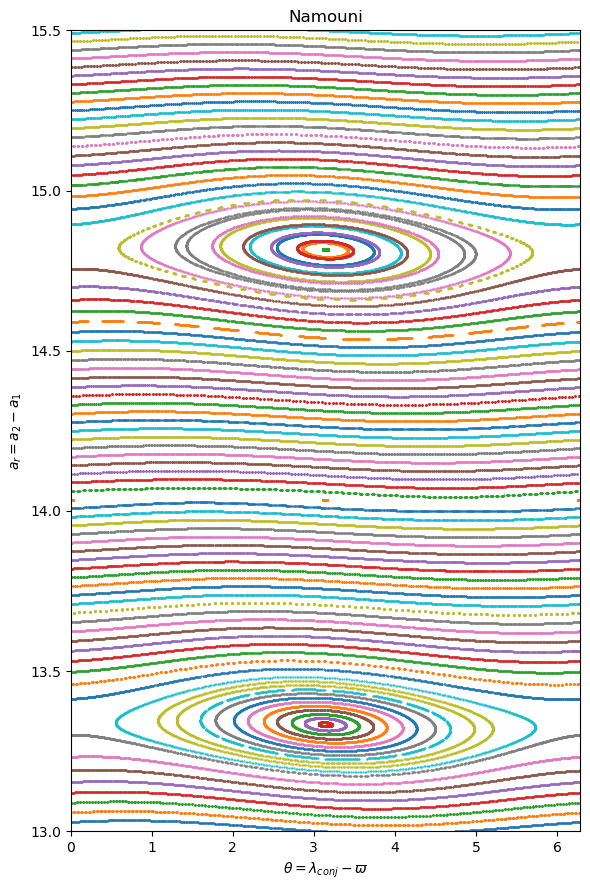

In [17]:
lambda0 = np.pi
phi0 = 0
I0 = 7**2/2 #in Namouni paper
epsilon = 5e-3  

#print(3/8*ar0_list[0]**2-I_list[0])
Na = 100 # number of original a values
ar0_list = np.linspace(13, 15.5, Na) # np.linspace(13.33447880751, 13.3345, Na) # list of a = a2-a1 values
I_list = 3/8*ar0_list**2 - 38.875 #for the same conserved quantity
ar_conj = np.zeros((len(ar0_list), Nconj))
theta_conj = np.zeros((len(ar0_list), Nconj))
# for i, ar in enumerate(ar0_list):
#     # initial conditions
#     In = I0
#     #In=I_list[i] 
#     Kn = 3/8*ar**2
#     arn = ar
#     lambdan = lambda0
#     phin = phi0
#     # integrating
#     for j in np.arange(Nconj):
#         if j == 0 and i==0:
#             print('phin', phin)
#             print('ar_conj', arn)
#             print('lambdan', lambdan)
#             print('In', In)
#             print('Kn', Kn)
        
#         Inp1, Knp1, phinp1, lambdanp1, hnp1, knp1 = namouni_so_step(In, Kn, phin, lambdan, ar, ind)
#         thetan = (lambdan-phin)% (2*np.pi)
#         thetanp1 = (lambdanp1-phinp1) % (2*np.pi)
        
#         # if thetan > np.pi:
#         #     thetan = thetan - 2*np.pi

#         ar_conj[i, j] = arn
#         theta_conj[i, j] = thetan
#         In, Kn, phin, lambdan = Inp1, Knp1, phinp1, lambdanp1
#         arn = np.sqrt(8/3*Kn)

ar_conj = np.zeros((len(ar0_list), Nconj+1))
theta_conj = np.zeros((len(ar0_list), Nconj+1))
K_conj = np.zeros((len(ar0_list), Nconj+1))
I_conj = np.zeros((len(ar0_list), Nconj+1))
for i, ar in enumerate(ar0_list):
    I0 = I_list[i]
    # initial conditions
    K0 = 3/8*ar**2
    #integrating
    Is, Ks, phis, lambdas, hs, ks = runmap(I0, K0, phi0, lambda0, Nconj, 2)
    thetas = (lambdas-phis) % (2*np.pi)
    #thetas = np.where(thetas>np.pi, thetas - 2*np.pi, thetas)
    ar_conj[i,:] = np.sqrt(8/3*Ks)
    theta_conj[i,:] = thetas
    I_conj[i,:] = Is
    K_conj[i,:] = Ks

#  plot
acol = ar0_list.reshape((Na, -1)) # column vector
a_arr = np.tile(acol, Nconj)
fig, ax = plt.subplots(figsize=(6,9))
ax.plot(theta_conj.T, ar_conj.T, '.', markersize=1)
ax.set_xlabel(r'$\theta = \lambda_{conj}-\varpi$') 
ax.set_ylabel('$a_r = a_2 - a_1$')
ax.set_title('Namouni')
# ax.set_xlim(-np.pi, np.pi)
ax.set_xlim(0, 2*np.pi)
ax.set_ylim(13,15.5)
#ax.axvline(.0026987345)
fig.tight_layout()

fig.savefig('namouni_cateye.png')


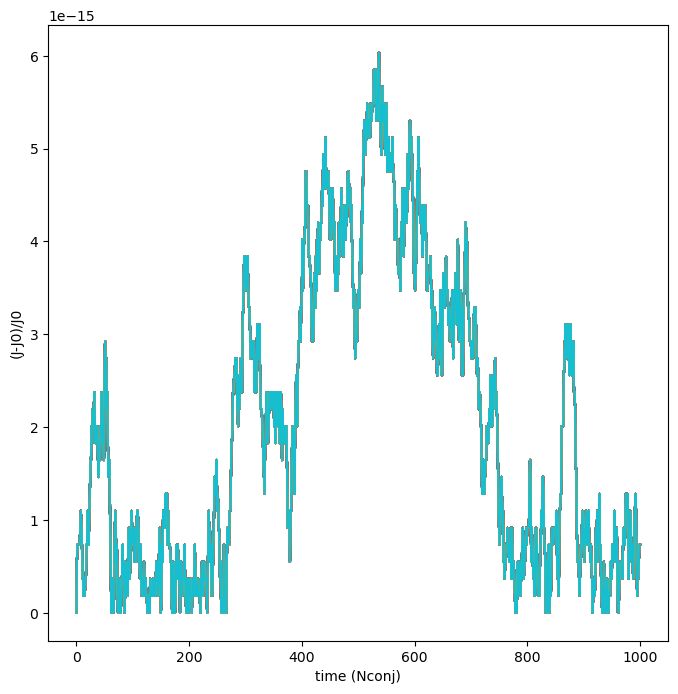

In [19]:
fig, ax = plt.subplots(figsize=(8,8))
J_conj = K_conj[i,:]-I_conj[i,:]
J0 = K_conj[0] - I_conj[0]
for i in range(len(ar0_list)):
    ax.plot(range(Nconj+1),np.abs((J_conj-J0)/J0))
ax.set_ylabel('(J-J0)/J0')
ax.set_xlabel("time (Nconj)")
plt.savefig('Jplot.png')
# ax.set_ylim(-0.0001,0.0001)

In [45]:
def namouni_fo_step_noapprox(In, Kn, phin, lambdan, arn):
    """First-order Namouni mapping step."""
    hn = np.sqrt(2*In)*np.cos(phin)
    kn = np.sqrt(2*In)*np.sin(phin)
    hprime = hn - 2*W1*np.sin(lambdan)/arn**2 # + for Namouni, - for pomega
    kprime = kn + 2*W1*np.cos(lambdan)/arn**2 # - for Namouni, + for pomega
    phiprime = np.arctan2(kprime, hprime) # 4 quadrant arctan
    #print(hn, kn)
    # both options should give the same result:
    Inprime = 1/2*(hprime**2 + kprime**2)
    #Inprime = In + 2*W1/arn**2*np.sqrt(2*In)*np.sin(thetan) + 2*W1**2/arn**4
    #Namouni update
    hnp1 = hprime
    knp1 = kprime
    Inp1 = Inprime
    Knp1 = Kn + Inp1 - In
    phinp1 = phiprime
    #lambdanp1 = lambdan + 4*np.pi/(3*epsilon*np.sqrt(8*Knp1/3))
    
    
    lambdanp1 = lambdan + 2*np.pi*np.abs(1/((1+np.sqrt(8*Knp1/3)*epsilon)**(-3/2)-1)) #same lambda
    
    return Inp1, Knp1, phinp1, lambdanp1, hnp1, knp1



In [16]:
def namouni_fo_step_abs(e1_vec_n, e2_vec_n, a1_conj_n, a2_conj_n, lambdan_n, ind):
    #hard calculate the relative values
    #print(e1_0, e2_0, pomega1_0, pomega2_0, a1_conj_0, a2_conj_0, lambdan_0)
    
    if ind==1:
        e12_vec = e2_vec_n - e1_vec_n
        ar_n = (a2_conj_n-a1_conj_n)/a1_conj_n/epsilon
        Kn = 3*ar_n**2/8
    else:
        e12_vec = e1_vec_n - e2_vec_n
        ar_n = (a1_conj_n-a2_conj_n)/a2_conj_n/epsilon
        Kn = 3*ar_n**2/8
    
    pomega12_temp = np.angle(e12_vec)
    e12_mag = np.sqrt((np.real(e12_vec))**2+(np.imag(e12_vec))**2)
    In = (e12_mag/epsilon)**2 / 2  
    hn = np.sqrt(2*In)*np.cos(pomega12_temp)
    kn = np.sqrt(2*In)*np.sin(pomega12_temp)  
    #phi0 = pomega12_temp

    #mapping calculation
    if ind == 1:
        hnp1 = hn - 2*W1*np.sin(lambdan_n)/ar_n**2 # + for Namouni, - for pomega
        knp1 = kn + 2*W1*np.cos(lambdan_n)/ar_n**2 # - for Namouni, + for pomega
    else:
        hnp1 = hn + 2*W1*np.sin(lambdan_n)/ar_n**2 # + for Namouni, - for pomega
        knp1 = kn - 2*W1*np.cos(lambdan_n)/ar_n**2 # - for Namouni, + for pomega
    #phiprime = np.arctan2(kprime, hprime) # 4 quadrant arctan
    
    # both options should give the same result:
    Inp1 = 1/2*(hnp1**2 + knp1**2)
    #Inprime = In + 2*W1/arn**2*np.sqrt(2*In)*np.sin(thetan) + 2*W1**2/arn**4
    
    #phinp1 = phiprime
    Knp1 = Kn + Inp1 - In
    lambdanp1 = lambdan_n + 4*np.pi/(3*epsilon*np.sqrt(8*Knp1/3))

    
    #e12np1_mag = np.sqrt(2*Inp1)*epsilon
    e12vec = hnp1*epsilon + 1j*knp1*epsilon
    
    if ind==1: #inner pair
        arnp1 = np.sqrt(8*Knp1/3)*epsilon*a1_conj_n
        e1np1 = e1_vec_n
        a1np1 = a1_conj_n
        e2np1 = e1_vec_n + e12vec
        a2np1 = a1_conj_n+arnp1
    else: #outer pair
        arnp1 = -np.sqrt(8*Knp1/3)*epsilon*a2_conj_n
        e1np1 = e2_vec_n + e12vec
        a1np1 = a2_conj_n + arnp1
        e2np1 = e2_vec_n
        a2np1 = a2_conj_n
    return e1np1, e2np1, a1np1, a2np1, lambdanp1
# optimize K and get the optimized a2 initial condition

In [17]:
def namouni_so_step_abs(e1_vec_n, e2_vec_n, a1_conj_n, a2_conj_n, lambdan_n, ind):
    #second order Namouni mapping that inputs and outputs individual values instead of the relative ones
    #hard calculate the relative values
    #print(e1_0, e2_0, pomega1_0, pomega2_0, a1_conj_0, a2_conj_0, lambdan_0)
    if ind==1:
        e12_vec = e2_vec_n - e1_vec_n
        ar_n = (a2_conj_n-a1_conj_n)/a1_conj_n/epsilon
        Kn = 3*ar_n**2/8
    else:
        e12_vec = e1_vec_n - e2_vec_n
        ar_n = (a1_conj_n-a2_conj_n)/a2_conj_n/epsilon
        Kn = 3*ar_n**2/8
    pomega12_temp = np.angle(e12_vec)
    e12_mag = np.sqrt((np.real(e12_vec))**2+(np.imag(e12_vec))**2)
    In = (e12_mag/epsilon)**2 / 2
    hn = np.sqrt(2*In)*np.cos(pomega12_temp)
    kn = np.sqrt(2*In)*np.sin(pomega12_temp)  
    #phi0 = pomega12_temp
    if ind == 1:
        hprime = hn - 2*W1*np.sin(lambdan_n)/ar_n**2 # + for Namouni, - for pomega
        kprime = kn + 2*W1*np.cos(lambdan_n)/ar_n**2 # - for Namouni, + for pomega
    else:
        hprime = hn + 2*W1*np.sin(lambdan_n)/ar_n**2 # + for Namouni, - for pomega
        kprime = kn - 2*W1*np.cos(lambdan_n)/ar_n**2 # - for Namouni, + for pomega
    phiprime = np.arctan2(kprime, hprime) # 4 quadrant arctan
    thetaprime = phiprime - lambdan_n

    # A = calc_coeff(2, W2, arn, thetaprime)
    # E1 = 1/(1+A)
    # Inp1 = E1*Inprime
    hnp1 = hprime
    knp1 = kprime
    Inp1 = (0.5*(hprime**2 + kprime**2)) / (1 + 4*W2*np.sin(2*thetaprime)*2/ar_n**3)
    phinp1 = phiprime - (W200 + 2*W2*np.cos(2*thetaprime))*2/ar_n**3
    Knp1 = Kn + Inp1 - In
    lambdanp1 = lambdan_n + 4*np.pi/(3*epsilon*np.sqrt(8*Knp1/3))

    
    #e12np1_mag = np.sqrt(2*Inp1)*epsilon
    e12vec = hnp1*epsilon + 1j*knp1*epsilon
    if ind==1: #inner pair
        arnp1 = np.sqrt(8*Knp1/3)*epsilon*a1_conj_n
        e1np1 = e1_vec_n
        a1np1 = a1_conj_n
        e2np1 = e1_vec_n + e12vec
        a2np1 = a1_conj_n+arnp1
    else: #outer pair
        arnp1 = -np.sqrt(8*Knp1/3)*epsilon*a2_conj_n
        e1np1 = e2_vec_n + e12vec
        a1np1 = a2_conj_n + arnp1
        e2np1 = e2_vec_n
        a2np1 = a2_conj_n
    return e1np1, e2np1, a1np1, a2np1, lambdanp1
# optimize K and get the optimized a2 initial condition

In [18]:
#DQT mapping - equivalent to Namouni but not scaled to Hill's unit
def dqt_step(lambdan, zn, epsn, eps0):
    #update
    znp1 = zn + 1j*g*np.exp(1j*lambdan)/eps0**2*np.sign(eps0)*mutot #ecc vector equivalent to h,k,pomega
    epsnp1 = epsn*np.sqrt(1+4*(np.abs(znp1)**2-np.abs(zn)**2)/(3*epsn**2)) #equivalent to K
    fenp1 = np.abs(1/((1+epsnp1)**(-3/2)-1)) #equivalent to change in lambda in terms of Knp1
    lambdanp1 = lambdan + 2*np.pi*fenp1 #same lambda
    phinp1 = np.angle(znp1)
    
    return lambdanp1, znp1, epsnp1

#This function runs dqt mapping for multiple conjunctions
def runmap_dqt(lambda0, z0, eps0, Nconj):
    try:                # minimize function later passes a 1-element list, so make it work for both scalar and list
        eps0 = eps0[0]
    except:
        pass
    lambda_d, z_d, eps_d = np.zeros(Nconj+1), np.zeros(Nconj+1,dtype = 'complex_'), np.zeros(Nconj+1)
    lambda_d[0] = lambda0
    z_d[0] = z0
    eps_d[0] = eps0

    for i in range(Nconj):
        lambda_d[i+1], z_d[i+1], eps_d[i+1] = dqt_step(lambda_d[i], z_d[i], eps_d[i], eps0)
        
    return lambda_d, z_d, eps_d


In [19]:
#This function runs Namouni mapping for multiple conjunctions
#But for individual parameters
def runmap_abs(e1_vec_0, e2_vec_0, a1_conj_0, a2_conj_0, lambdan_0, Nconj, ind, order):
    try:                # minimize function later passes a 1-element list, so make it work for both scalar and list
        a1_conj_0 = a1_conj_0[0]
    except:
        pass
    e1_s, e2_s, a1_s, a2_s, lambda_s = np.zeros(Nconj+1,dtype = 'complex_'), np.zeros(Nconj+1,dtype = 'complex_'), np.zeros(Nconj+1), np.zeros(Nconj+1), np.zeros(Nconj+1)
    #print(e1_vecarr, e2_vecarr)
    e1_s[0] = e1_vec_0
    e2_s[0] = e2_vec_0
    #print(e1_s[0], e2_s[0])
    #print(a1_conj_0, a2_conj_0)
    a1_s[0] = a1_conj_0
    a2_s[0] = a2_conj_0
    lambda_s[0] = lambdan_0
    #ar0 = np.sqrt(8*K0/3)
    for i in range(Nconj):
        if order==1:
            e1_s[i+1], e2_s[i+1], a1_s[i+1], a2_s[i+1], lambda_s[i+1] = namouni_fo_step_abs(e1_s[i], e2_s[i], a1_s[i], a2_s[i], lambda_s[i], ind)
        else:
            e1_s[i+1], e2_s[i+1], a1_s[i+1], a2_s[i+1], lambda_s[i+1] = namouni_so_step_abs(e1_s[i], e2_s[i], a1_s[i], a2_s[i], lambda_s[i], ind)            

    return e1_s, e2_s, a1_s, a2_s, lambda_s

In [20]:
#running for N conjunctions
def runmap_noapprox(I0, K0, phi0, lambda0, Nconj, order):
    try:                # minimize function later passes a 1-element list, so make it work for both scalar and list
        K0 = K0[0]
    except:
        pass
    Isn, Ksn, phisn, lambdasn, hsn, ksn = np.zeros(Nconj+1), np.zeros(Nconj+1), np.zeros(Nconj+1), np.zeros(Nconj+1), np.zeros(Nconj+1), np.zeros(Nconj+1)
    Isn[0] = I0
    Ksn[0] = K0
    phisn[0] = phi0
    lambdasn[0] = lambda0
    ar0 = np.sqrt(8*K0/3)

    for i in range(Nconj):
        if order==1:
            Isn[i+1], Ksn[i+1], phisn[i+1], lambdasn[i+1], hsn[i+1], ksn[i+1] = namouni_fo_step_noapprox(Isn[i], Ksn[i], phisn[i], lambdasn[i], ar0)
        else:
            Isn[i+1], Ksn[i+1], phisn[i+1], lambdasn[i+1], hsn[i+1], ksn[i+1] =namouni_fo_step_noapprox(Isn[i], Ksn[i], phisn[i], lambdasn[i], ar0)

    return Isn, Ksn, phisn, lambdasn, hsn, ksn